In [1]:
from utils import DataHandler
from ESN import ESNetwork, ClassicalRC
from reservoirs import CPRC
import matplotlib.pyplot as plt
from copy import deepcopy
import numpy as np

In [3]:
feedback_gain = 0.5  # Tune this value based on your system
dim = 10
cprc = CPRC(dim=dim, execution_mode='simulation', kernel = True)

In [4]:
# Create two identical reservoirs with different seeds for initial feedback states
esn_1 = ESNetwork(
    reservoir=cprc, 
    dim=dim, 
    regularization=1e-6, 
    alpha=0.79, 
    show_progress=True, 
    approach='feedback', # 'feedback', or 'time-multiplexing'
    model_type='ridge',  # Options: 'ridge', 'lasso', 'linear', 'svr', 'svc'
    limit = 0.9,
    cpk = True
)
esn_2 = ESNetwork(
    reservoir=cprc, 
    dim=dim, 
    regularization=1e-6, 
    alpha=0.79, 
    show_progress=True, 
    approach='feedback', # 'feedback', or 'time-multiplexing'
    model_type='ridge',  # Options: 'ridge', 'lasso', 'linear', 'svr', 'svc'
    limit = 0.9,
    cpk = True
)

# Manually set different initial feedback (simulates different initial states)
esn_1.prev_output = np.random.rand(esn_1.dim)
esn_2.prev_output = np.random.rand(esn_2.dim)

# Create identical input sequence
T = 10
X_input = np.random.rand(T, esn_1.dim)  # Shape = (timesteps, features)
dummy_target = np.zeros((T,))  # Dummy target just to enable 'fit'

# Fit both ESNs (to collect internal states)
esn_1.fit(X_input, dummy_target)
esn_2.fit(X_input, dummy_target)

# Retrieve quantum states
states_1 = esn_1.get_saved_states()
states_2 = esn_2.get_saved_states()

# Compute distance at each timestep
distances = np.linalg.norm(states_1 - states_2, axis=1)

# Plot
plt.figure(figsize=(10, 4))
plt.plot(distances, label='State Distance')
plt.xlabel("Time Step")
plt.ylabel("L2 Distance")
plt.title("Echo State Property Check (with Feedback)")
plt.legend()
plt.grid(True)
plt.show()


raining Progress: 100%|███████████████████| 10/10 [00:00<00:00, 27.57 sample/s]

ValueError: Expected 2D array, got 1D array instead:
array=[].
Reshape your data either using array.reshape(-1, 1) if your data has a single feature or array.reshape(1, -1) if it contains a single sample.

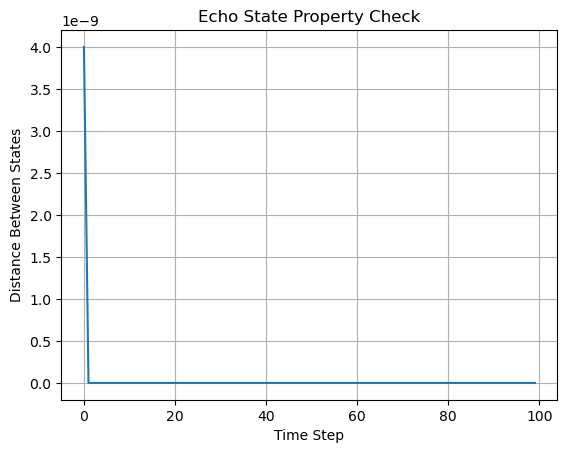

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# Sample reservoir update function
def reservoir_step(state, input_val, W_res, W_in):
    return np.tanh(W_res @ state + W_in * input_val)

# Reservoir parameters
N = 100
T = 100
W_res = np.random.rand(N, N) * 0.9  # Ensure spectral radius < 1
W_in = np.random.rand(N)

# Same input sequence
inputs = np.random.rand(T)

# Different initial states
state1 = np.random.rand(N)
state2 = np.random.rand(N) * 0.5  # Slightly different

distances = []

# Run both reservoirs on the same input
for x in inputs:
    state1 = reservoir_step(state1, x, W_res, W_in)
    state2 = reservoir_step(state2, x, W_res, W_in)
    
    dist = np.linalg.norm(state1 - state2)
    distances.append(dist)

# Plot the distance
plt.plot(distances)
plt.xlabel("Time Step")
plt.ylabel("Distance Between States")
plt.title("Echo State Property Check")
plt.grid(True)
plt.show()


In [11]:
from circuits import CPCircuit

In [16]:
from utils import DataHandler
from ESN import ESNetwork
from reservoirs import CPRC
from backend import QuantumBackendSelector

In [30]:
selector = QuantumBackendSelector(use_simulation=False, provider="IBMQ", 
                                  ibmq_token="08c051f22a4ffff00f5ff10d115109744a167d96680e05a22399300f89764b8cd986afdf77de4915a44886da1de734d619bc6fed6101e50dfc96b00db5026c86",
                                  ibmq_instance = 'ibm-q/open/main',
                                  backend_name = 'ibm_quebec')

Failed to initialize IBMQ backend: 'No backend matches the criteria.'
Using Qiskit primitive Estimator (simulation).


In [19]:
backend_info = selector.get_backend_info()
backend = backend_info[0]

In [12]:
cp = CPCircuit(5)

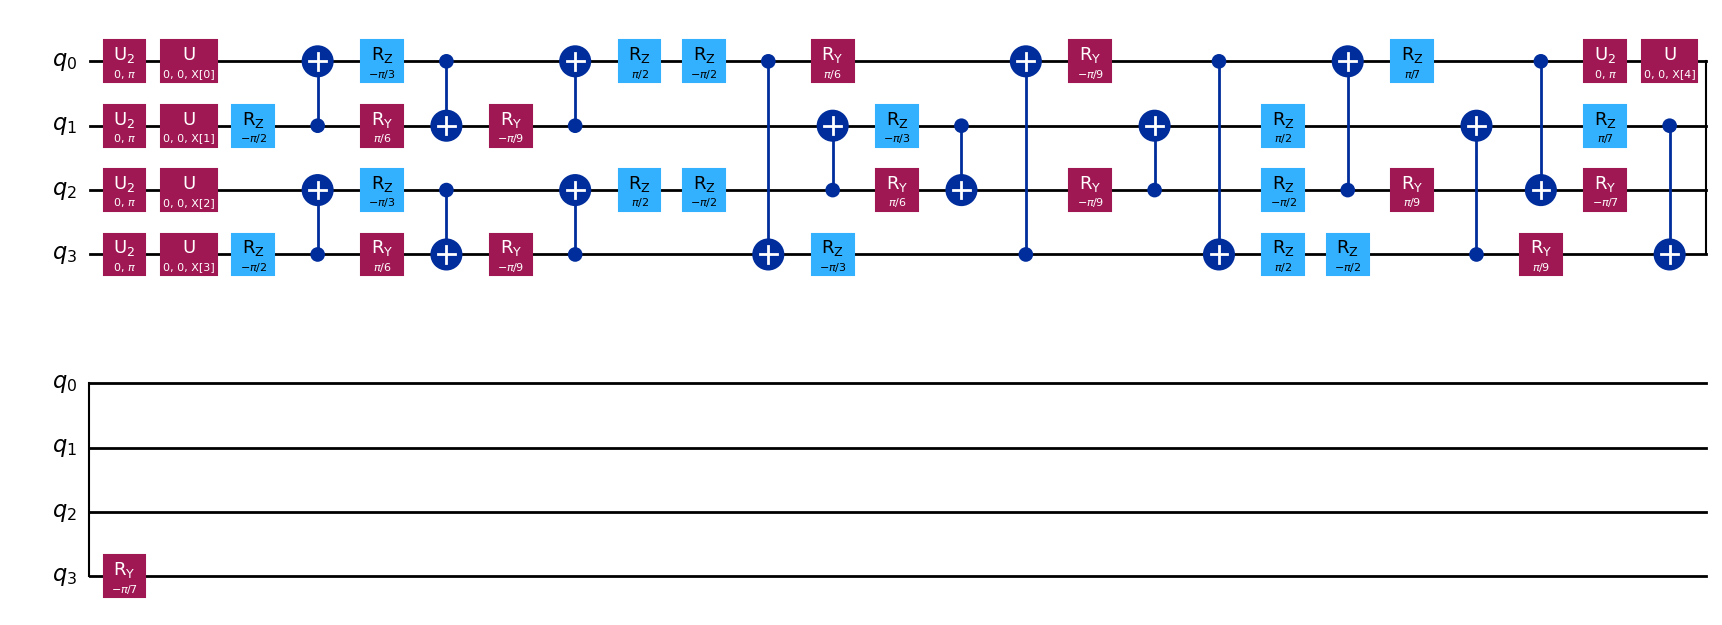

In [15]:
qc = cp.CPMap()
qc.decompose().draw('mpl')

In [26]:
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
pass_manager = generate_preset_pass_manager(backend=backend, optimization_level=1)
qcc = pass_manager.run(qc)

In [27]:
qcc.count_ops()

OrderedDict([('rz', 92), ('sx', 58), ('ecr', 25), ('x', 2)])

In [25]:
qcc.count_ops()

OrderedDict([('rz', 95), ('sx', 61), ('ecr', 25), ('x', 6)])

In [23]:
qcc.count_ops()

OrderedDict([('rz', 94), ('sx', 64), ('ecr', 25), ('x', 1)])

In [35]:
from meteostat import Point, Daily
from datetime import datetime

# Location and time
ottawa = Point(45.4215, -75.6972)
start = datetime(2015, 1, 1)
end = datetime(2023, 12, 31)

data = Daily(ottawa, start, end)
data = data.fetch()
print(data.head())


            tavg  tmin  tmax  prcp  snow   wdir  wspd  wpgt    pres  tsun
time                                                                     
2015-01-01  -5.1  -7.4  -2.7   0.0  10.0  223.0  20.4   NaN  1008.1   NaN
2015-01-02  -8.8 -14.0  -3.5   0.0  20.0  282.0  14.4   NaN  1021.4   NaN
2015-01-03 -11.6 -14.3  -8.8  10.1  10.0   66.0  15.6   NaN  1030.4   NaN
2015-01-04  -4.5  -8.8  -0.2   2.5  80.0   20.0   5.0   NaN  1004.5   NaN
2015-01-05 -15.1 -21.3 -10.0   0.2  60.0  360.0   0.0   NaN  1020.2   NaN


In [36]:
import pandas as pd

In [39]:
df= pd.read_csv('Data/DailyDelhiClimateTrain.csv')

In [40]:
df.head(10)

,date,meantemp,humidity,wind_speed,meanpressure
0,2013-01-01,10.000000,84.500000,0.000000,1015.666667
1,2013-01-02,7.400000,92.000000,2.980000,1017.800000
2,2013-01-03,7.166667,87.000000,4.633333,1018.666667
3,2013-01-04,8.666667,71.333333,1.233333,1017.166667
4,2013-01-05,6.000000,86.833333,3.700000,1016.500000
5,2013-01-06,7.000000,82.800000,1.480000,1018.000000
6,2013-01-07,7.000000,78.600000,6.300000,1020.000000
7,2013-01-08,8.857143,63.714286,7.142857,1018.714286
8,2013-01-09,14.000000,51.250000,12.500000,1017.000000
9,2013-01-10,11.000000,62.000000,7.400000,1015.666667


In [41]:
df.to_numpy().shape

(1462, 5)